In [42]:
%matplotlib ipympl

In [1]:
import pandas as pd
from prophet import Prophet
from datetime import date
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from scipy.stats.mstats import winsorize
from noaa.noaa_snowflake import get_noaa_weather_data

In [2]:
client = ModoEnergyAPIClient(cache_requests=True)

In [3]:
start = date(2022, 9, 11)
end = date(2026, 5, 31)

In [31]:
ercot_bess = client.ercot_bess_owners(
    date_from=start,
    date_to=end,
)

ercot_bess["month"] = ercot_bess["date"].dt.to_period("M").dt.to_timestamp()
ercot_bess_capacity = (
    ercot_bess.groupby("month")
    .agg({"total_energy_capacity_mwh": "mean"})
    .rename(columns={"total_energy_capacity_mwh": "bess_capacity"})
    .resample("D")
    .ffill()
)[["bess_capacity"]]

Fetching pages : 0page [00:00, ?page/s]

In [7]:
prices = client.get_ercot_prices(date_from=start, date_to=end)

hub_prices = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
]

hub_prices_winsorized = pd.DataFrame(
    {hub_prices.name: winsorize(hub_prices, limits=[None, 0.01])},
    index=hub_prices.index,
)

arbitrage_opportunity = (
    hub_prices_winsorized.resample("D")
    .agg(lambda d: max(d[d.index.hour == 19].item() - d[d.index.hour == 12].item(), 0))
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
)

Fetching pages : 0page [00:00, ?page/s]

In [ ]:
houston_weather_station_id = "USW00012960"
wind_data = get_noaa_weather_data(
    start, end, noaa_weather_station_id=houston_weather_station_id
)
wind_data = wind_data["Average daily wind speed"].ffill()

In [36]:
joined_data = arbitrage_opportunity.join(wind_data, how="inner").join(
    ercot_bess_capacity, how="left"
)
prophet_data = (
    joined_data.reset_index()
    .rename(
        columns={
            "deliveryDate": "ds",
            "arbitrage_opportunity": "y",
            "Average daily wind speed": "wind_speed",
        }
    )
    .ffill()
)

In [38]:
model = Prophet(mcmc_samples=300)
model.add_regressor("wind_speed")
model.add_regressor("bess_capacity")
model.fit(prophet_data)

01:22:54 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

01:23:02 - cmdstanpy - INFO - CmdStan done processing.
01:23:02 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, c

In [39]:
fitted = model.predict(prophet_data)

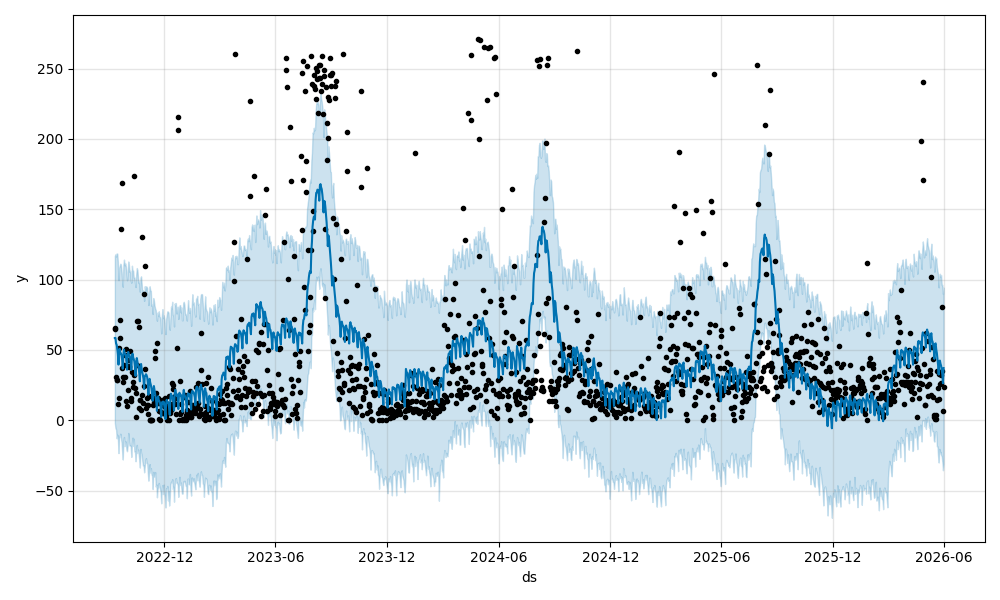

In [43]:
fig1 = model.plot(fitted)


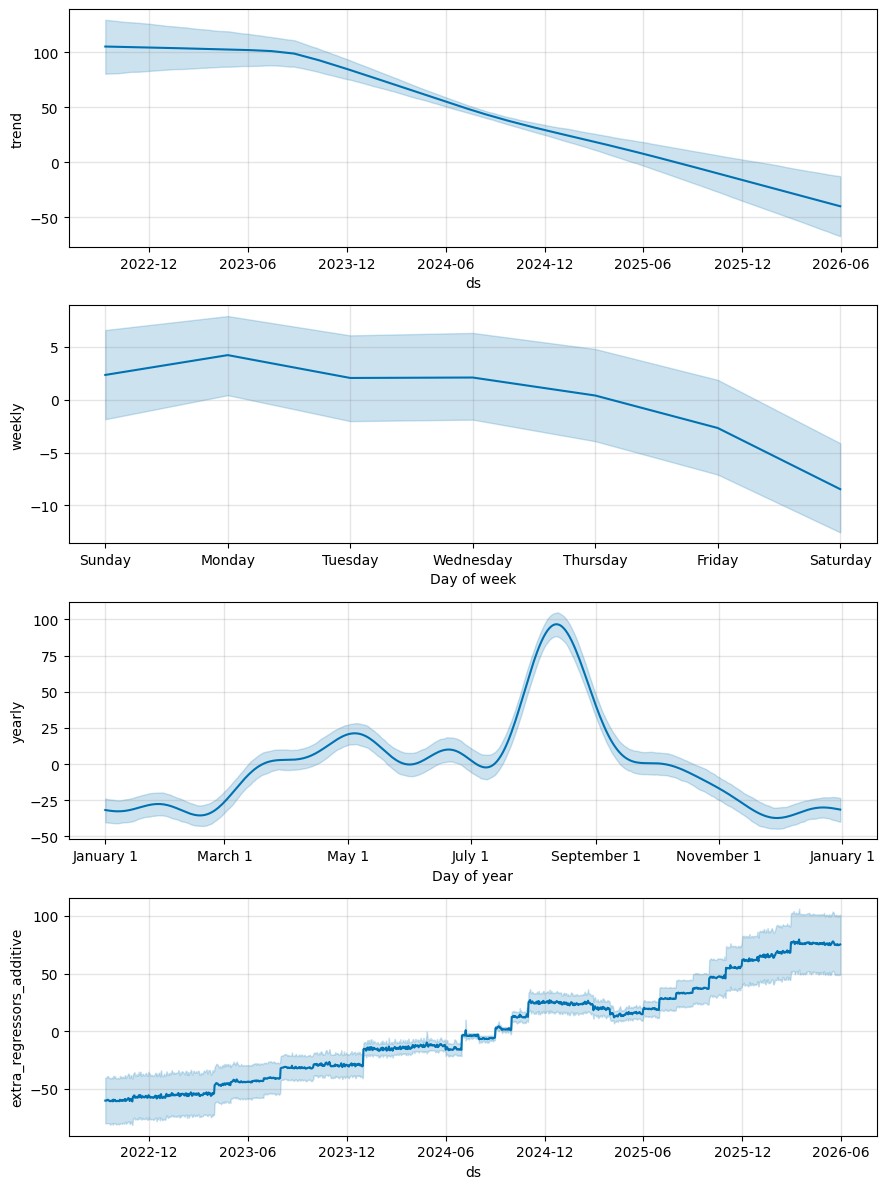

In [41]:
fig2 = model.plot_components(fitted)
